You’re looking at a **one-dimensional surrogate** of Noorman’s network equation. Here is the mapping.

* Paper’s single-neuron rate equation (center ring, dropping velocity for clarity):
  $\tau \dot h_j = -h_j + \tfrac1N\sum_k W^{\text{sym}}_{jk}\,\phi(h_k) + c_{\mathrm{ff}}$, with $\phi(x)=[x]_+$. They use $\tau=0.1\,\text{s}$ and typically set $c_{\mathrm{ff}}=1$. $W^{\text{sym}}_{jk}=J_I+J_E\cos(\theta_j-\theta_k)$.&#x20;

* Our **scalar reduction** keeps only one latent variable $h$ and replaces the recurrent sum by a single gain $w_{\mathrm{eff}}$:
  $\tau_{\text{rate}}\dot h = -h + c_{\mathrm{ff}} + w_{\mathrm{eff}}\,[h]_+$.
  Here, $w_{\mathrm{eff}}$ is the **effective self-feedback** that compresses the active submatrix of $W^{\text{sym}}$ at the operating point into one number. In the paper’s linear “active-subset” view, dynamics of active neurons are $\dot{\mathbf h}_{\text{act}} = \tfrac1\tau(-I+\tfrac{1}{N}W^{\text{sym}})\mathbf h_{\text{act}} + c_{\mathrm{ff}}\mathbf e$; collapsing along the bump mode yields a scalar coefficient. That scalar is what we call $w_{\mathrm{eff}}$.&#x20;

* Intuition for $w_{\mathrm{eff}}$. With threshold-linear $\phi$ and a fixed active set, $\phi'(h_k)=1$. The net recurrent input to unit $j$ scales like the **row-average of $W^{\text{sym}}$ over the active neighbors**, i.e., roughly
  $w_{\mathrm{eff}}\;\approx\; \tfrac{1}{N}\!\sum_{k\in K_{\text{act}}}\!\big[J_I+J_E\cos(\theta_j-\theta_k)\big]$.
  This links $w_{\mathrm{eff}}$ back to $J_E,J_I$ and to the bump width via the active set $K_{\text{act}}$ (the paper formalizes these averages with $f_0, f_{\text{even}}$ in the bump equations).&#x20;

* Why $c_{\mathrm{ff}} = h_\star(1-w_{\mathrm{eff}})$. At a chosen operating point $h_\star>0$ and no external drive, steady state requires
  $0 = -h_\star + c_{\mathrm{ff}} + w_{\mathrm{eff}}[h_\star]_+ \Rightarrow c_{\mathrm{ff}}=h_\star(1-w_{\mathrm{eff}})$.
  This is just the **fixed-point condition** for the scalar surrogate, matching the paper’s use of a constant feedforward term $c_{\mathrm{ff}}$ to set the baseline together with recurrent feedback.&#x20;

* Your numbers: `w_eff = 0.8`, `h_star = 0.20` ⇒ `c_ff = 0.04`.
  This does **not** try to reproduce the paper’s literal $c_{\mathrm{ff}}=1$. It sets a **convenient local operating point** for the reduced model so we can calibrate the LIF. In the full network, $c_{\mathrm{ff}}$ interacts with $J_E,J_I$ and bump geometry; our $w_{\mathrm{eff}}$ absorbs that interaction into one scalar near $h_\star$.&#x20;

* If you want $w_{\mathrm{eff}}$ from $J_E,J_I$ explicitly: pick $N$ and a bump width $w$. Define the active set $K_{\text{act}}=\{\theta_k\in(\psi-w/2,\psi+w/2)\}$. Then use the row-average formula above to compute $w_{\mathrm{eff}}$ for that geometry, or use the paper’s $f_0, f_{\text{even}}$ functions (Eqs. S18–S22) to get the same quantities analytically and convert to a scalar gain around your $(w,\psi)$.&#x20;

In short:

* $c_{\mathrm{ff}}$ is the paper’s constant feedforward input.
* $w_{\mathrm{eff}}$ is your one-number stand-in for $J_E,J_I$ acting through the active submatrix at the chosen bump.
* $c_{\mathrm{ff}}=h_\star(1-w_{\mathrm{eff}})$ pins the fixed point of the reduced equation.


In [1]:
# Noorman rate → LIF: general mapping with correct units throughout.
# Match at operating point h*>0: value, slope, and time scale.
# Rate unit: τ_rate dh/dt = -h + c_ff + w_eff·[h]+ + u(t), r = [h]+ (dimensionless).
# Map to LIF via μ(t) = α·h(t) + β (volt). Calibrate α, β at h*.

from brian2 import *
import numpy as np

defaultclock.dt = 0.1*ms

# ------------------- Noorman rate unit (single cell) -------------------
tau_rate = 100*ms
w_eff    = 0.8

h_star = 0.20        # dimensionless, choose >0
c_ff   = h_star*(1 - w_eff)  # fixed point for u=0
print(f'Operating point h*={h_star:.3f}, c_ff={c_ff:.3f}')

# External perturbation u(t) (dimensionless)
T = 5*second
steps = int(T/defaultclock.dt)
u_arr = np.zeros(steps)
mask = (np.arange(steps)*defaultclock.dt >= 0.5*second) & (np.arange(steps)*defaultclock.dt < 1.0*second)
u_arr[mask] = 0.00
u = TimedArray(u_arr, dt=defaultclock.dt)  # dimensionless

# For comparison only: convert [h]+ to Hz with α_Hz
alpha_Hz = 500.0*Hz  # Hz per unit h

rate_eqs = '''
dh/dt = (-h + cff + w_eff * r + u(t))/tau_rate : 1
r = clip(h, 0, inf) : 1
cff : 1
w_eff : 1
r_hz = alphaHz * r : Hz
alphaHz : Hz
'''
rate = NeuronGroup(1, rate_eqs, method='euler')
rate.h = 0.0
rate.cff = c_ff
rate.w_eff = w_eff
rate.alphaHz = alpha_Hz


Operating point h*=0.200, c_ff=0.040


In [2]:
# ------------------- LIF neuron (current-based) -------------------
tau_m = tau_rate/10                      # match dominant pole
t_ref = 2*ms
V_th  = -48*mV
V_r   = -80*mV
E_L   = -70*mV
sigma = 0.0*volt             # keep 0 for deterministic mapping

# Deterministic LIF f-I and gain (unit-safe)
def lif_rate_dc(mu):
    if mu <= V_th:
        return 0.0*Hz
    Tperi = t_ref + tau_m*log((mu - V_r)/(mu - V_th))  # seconds
    return 1.0/Tperi                                   # Hz

def lif_gain_dc(mu):
    if mu <= V_th:
        return 0.0*Hz/volt
    Tperi = t_ref + tau_m*log((mu - V_r)/(mu - V_th))  # s
    dT_dmu = tau_m*((1.0/(mu - V_r)) - (1.0/(mu - V_th)))  # s/volt
    return -(1.0/(Tperi*Tperi))*dT_dmu                 # Hz/volt

# --- Calibration at h* ---
r_star_Hz = alpha_Hz * h_star        # since h*>0 → r=[h]+=h*

In [3]:
# Add this before trying to solve
test_voltage = V_th + 50*mV  # Try a voltage well above threshold
max_rate = lif_rate_dc(test_voltage)
print(f"Maximum achievable firing rate at {test_voltage}: {max_rate}")
print(f"Target rate: {r_star_Hz:.2f}")

Maximum achievable firing rate at 2. mV: 143.94780622 Hz
Target rate: 100.00


In [4]:
# Solve μ* s.t. lif_rate_dc(μ*) = r_star_Hz  (bisection, unit-safe)
def solve_mu_star(target_rate, lo=V_th + 1e-9*volt, hi=V_th + 0.5*volt):
    a, b = lo, hi
    fa = lif_rate_dc(a) - target_rate
    fb = lif_rate_dc(b) - target_rate
    print(f"Initial bracketing: [{a}, {b}], lif_rate_a = {lif_rate_dc(a)}, lif_rate_b = {lif_rate_dc(b)}, f(a)={fa}, f(b)={fb}")
    if fa*fb > 0.0*Hz**2:
        raise RuntimeError("Increase 'hi'; target not bracketed.")
    for _ in range(500):
        m = 0.5*(a+b)
        fm = lif_rate_dc(m) - target_rate
        if abs(fm) < 1e-9*Hz:
            return m
        if fa*fm < 0*Hz**2:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return 0.5*(a+b)

mu_star = solve_mu_star(r_star_Hz)   # volt
chi0    = lif_gain_dc(mu_star)       # Hz/volt
s_star  = alpha_Hz                   # d(α_Hz·[h]+)/dh = α_Hz for h*>0
alpha_v = (s_star/chi0)              # volt per unit h
beta_v  = mu_star - alpha_v*h_star   # volt

print(f"[cal] h*={h_star:.3f}, r*(Hz)={r_star_Hz:.3f}")
print(f"[cal] mu*={mu_star:.6f}, chi0={chi0/(Hz/volt):.4f} Hz/V, alpha={alpha_v/volt:.6f}, beta={beta_v:.6f}")


Initial bracketing: [-47.999999 mV, 0.452 V], lif_rate_a = 5.72041588 Hz, lif_rate_b = 0.38162784 kHz, f(a)=-94.27958412 Hz, f(b)=281.62783908 Hz
[cal] h*=0.200, r*(Hz)=100.000
[cal] mu*=-0.021889, chi0=2108.9684 Hz/V, alpha=0.237083, beta=-0.069306


In [5]:

# LIF driven by μ(t) = α·h(t) + β
lif_eqs = """
dV/dt = (E_L - V + mu)/tau_m + sigma*xi*tau_m**(-0.5) : volt (unless refractory)
mu = alpha*h_link + beta : volt
alpha : volt
beta  : volt
h_link : 1 (linked)
"""
lif = NeuronGroup(1, lif_eqs, threshold='V > V_th', reset='V = V_r',
                  refractory=t_ref, method='euler')
lif.run_regularly('V = clip(V, V_r, inf*volt)', dt=defaultclock.dt)
lif.V = V_r
lif.alpha = alpha_v
lif.beta  = beta_v
lif.h_link = linked_var(rate, 'h')

# ------------------- Monitors -------------------
M_rate = StateMonitor(rate, ['h', 'r', 'r_hz'], record=True)
M_mu   = StateMonitor(lif,  ['mu'], record=True)
M_V = StateMonitor(lif, 'V', record=True)
S_lif  = SpikeMonitor(lif)
PR_lif = PopulationRateMonitor(lif)

run(T)

# ------------------- Checks (unit-safe) -------------------
# Window rates via counts/time
n0 = np.sum(S_lif.t < 0.5*second)
n1 = np.sum((S_lif.t >= 0.5*second) & (S_lif.t < 1.0*second))
r_lif_0 = n0/(0.5*second)   # Hz
r_lif_1 = n1/(0.5*second)   # Hz

# Target and theoretical LIF in the same windows
w0 = slice(0, int(0.5*second/defaultclock.dt))
w1 = slice(int(0.5*second/defaultclock.dt), int(1.0*second/defaultclock.dt))

r_target_0 = sum(M_rate.r_hz[0][w0]) / len(M_rate.r_hz[0][w0])   # Hz
r_target_1 = sum(M_rate.r_hz[0][w1]) / len(M_rate.r_hz[0][w1])   # Hz
mu0 = sum(M_mu.mu[0][w0]) / len(M_mu.mu[0][w0])                  # volt
mu1 = sum(M_mu.mu[0][w1]) / len(M_mu.mu[0][w1])                  # volt
r_lif_th_0 = lif_rate_dc(mu0)                                    # Hz
r_lif_th_1 = lif_rate_dc(mu1)                                    # Hz

print(f"[win0] target={r_target_0:.2f}, lif_emp={r_lif_0:.2f}, lif_theo={r_lif_th_0:.2f}")
print(f"[win1] target={r_target_1:.2f}, lif_emp={r_lif_1:.2f}, lif_theo={r_lif_th_1:.2f}")

WARNING    'w_eff' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 0.8. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[win0] target=36.78, lif_emp=0.00, lif_theo=0.00
[win1] target=76.75, lif_emp=0.00, lif_theo=74.72


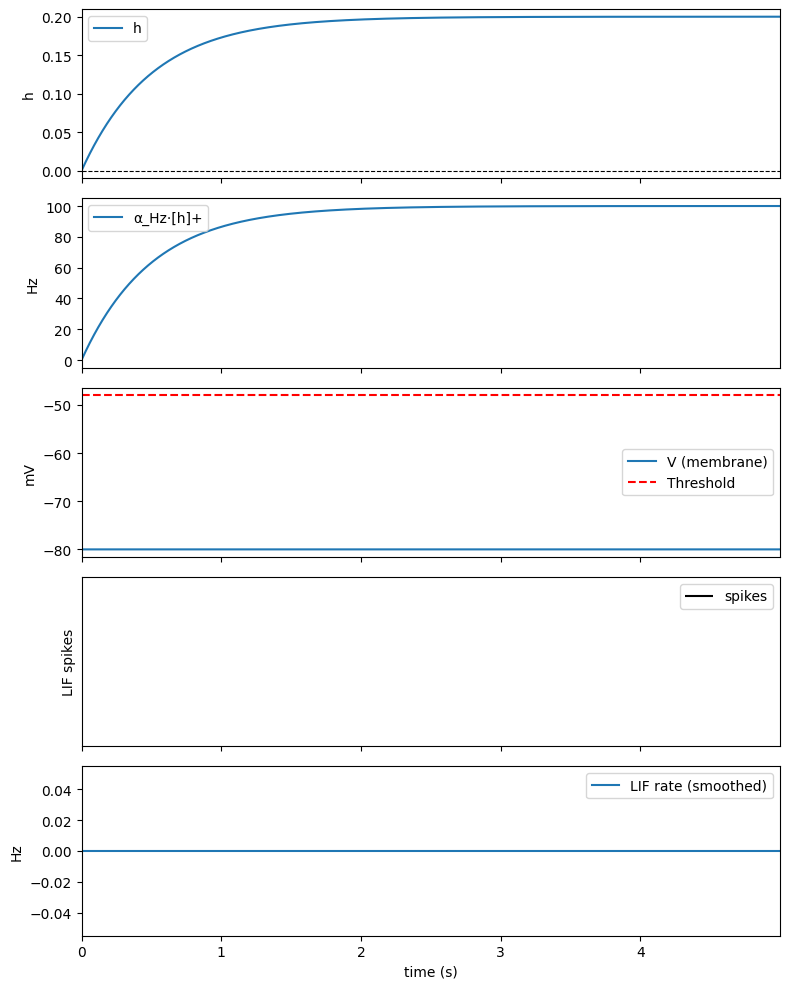

In [6]:
# Then modify your plotting code to include the voltage trace
import matplotlib.pyplot as plt
t = M_rate.t/second
fig, ax = plt.subplots(5, 1, figsize=(8, 10), sharex=True)  # Changed to 5 subplots

ax[0].plot(t, M_rate.h[0], label='h')
ax[0].axhline(0, ls='--', lw=0.8, color='k'); ax[0].set_ylabel('h'); ax[0].legend()

ax[1].plot(t, (M_rate.r_hz[0]/Hz), label='α_Hz·[h]+')
ax[1].set_ylabel('Hz'); ax[1].legend()

# Add voltage plot here
ax[2].plot(t, M_V.V[0]/mV, label='V (membrane)')
ax[2].axhline(V_th/mV, ls='--', color='r', label='Threshold')
ax[2].set_ylabel('mV'); ax[2].legend()

# Raster plot for LIF neuron
ax[3].eventplot(S_lif.t/second, lineoffsets=0.0, colors='k')
ax[3].set_ylabel('LIF spikes')
ax[3].set_yticks([])
ax[3].set_xlim([t[0], t[-1]])
ax[3].legend(['spikes'])

# Population rate plot
ax[4].plot(t, (PR_lif.smooth_rate(window='gaussian', width=1*ms)/Hz), label='LIF rate (smoothed)')
ax[4].set_ylabel('Hz'); ax[4].set_xlabel('time (s)'); ax[4].legend()

plt.tight_layout(); plt.show()